# FemFit — Adaptive TDEE & Cycle-Weight Analysis

The data-science layer behind [FemFit](../README.md): turning a user's daily logs (weight, calorie intake, steps, menstrual cycle) into two evidence-based features that go beyond textbook formulas.

**Why synthetic data here is a feature, not a cop-out:** you *cannot* validate a maintenance-calorie (TDEE) estimator on real data, because a person's true TDEE is unobservable — there is no ground truth. So we generate data with a *known* injected TDEE and a *known* cycle water-retention effect, and check the estimators recover them. The exact same code then runs on real data — see the last section.

In [1]:
import sys; sys.path.insert(0, '.')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from data import load_data
from adaptive_tdee import estimate_tdee, expanding_tdee
from cycle_analysis import analyze, detrend_weight

plt.rcParams.update({'figure.figsize': (9, 4), 'axes.grid': True,
                     'grid.alpha': 0.3, 'figure.dpi': 110})
PHASE_COLORS = {'menstrual': '#fca5a5', 'follicular': '#86efac',
                'ovulation': '#fde047', 'luteal': '#c4b5fd'}
PHASE_ORDER = ['menstrual', 'follicular', 'ovulation', 'luteal']

## 1. Load data

`load_data` returns a canonical daily table regardless of source. Here we load 120 synthetic days with a true TDEE of 2000 kcal and an injected luteal water-retention peak of 0.8 kg.

In [2]:
df, gt = load_data('synthetic', n_days=120, true_tdee=2000, deficit=350,
                   luteal_peak_kg=0.8, seed=42)
print('Ground truth:', gt)
df.head()

Ground truth: GroundTruth(true_tdee=2000, deficit=350, luteal_peak_kg=0.8, start_weight_kg=68.0, expected_kg_per_week=-0.3181818181818182)


,date,day,cycle_day,phase,steps,intake_kcal,latent_weight_kg,weight_kg
0,2026-01-01,0,8,follicular,8762,1425,68.000,67.78
1,2026-01-02,1,9,follicular,5400,1689,67.921,67.90
2,2026-01-03,2,10,follicular,9876,1878,67.895,67.46
3,2026-01-04,3,11,follicular,10351,2129,67.869,67.50
4,2026-01-05,4,12,follicular,3122,1834,67.874,68.41


## 2. The problem: scale weight is noisy and cycle-confounded

Observed weight = slow fat-mass trend + **cyclic water retention** + daily hydration noise. The luteal/pre-menstrual rise is water, not fat — the shaded phases below make the confound visible. A naive day-to-day reading would panic the user.

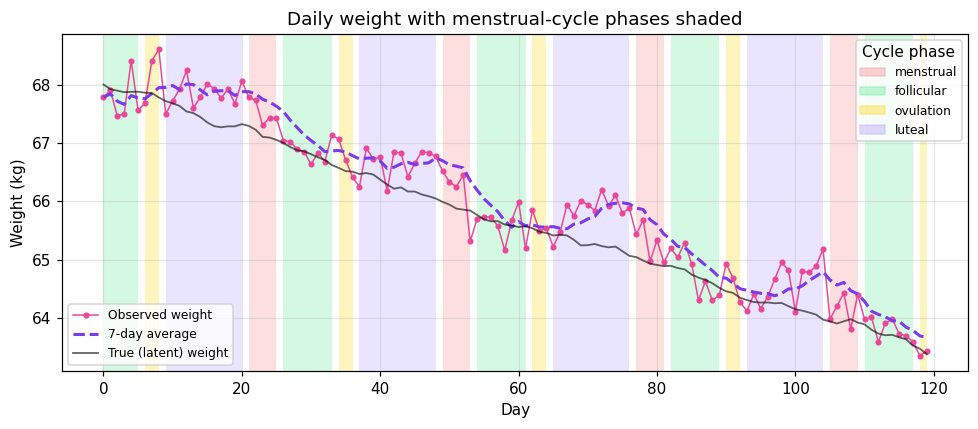

In [3]:
fig, ax = plt.subplots()
prev, start = None, 0
for i, ph in enumerate(df.phase):
    if ph != prev:
        if prev is not None:
            ax.axvspan(start, df.day.iloc[i - 1], color=PHASE_COLORS[prev], alpha=0.35, lw=0)
        prev, start = ph, df.day.iloc[i]
ax.axvspan(start, df.day.iloc[-1], color=PHASE_COLORS[prev], alpha=0.35, lw=0)
ax.plot(df.day, df.weight_kg, color='#ec4899', lw=1, marker='o', ms=3, label='Observed weight')
ax.plot(df.day, df.weight_kg.rolling(7, min_periods=1).mean(), color='#7c3aed', lw=2, ls='--', label='7-day average')
if 'latent_weight_kg' in df.columns:
    ax.plot(df.day, df.latent_weight_kg, color='black', lw=1.2, alpha=0.6, label='True (latent) weight')
handles = [plt.Rectangle((0, 0), 1, 1, color=PHASE_COLORS[p], alpha=0.5) for p in PHASE_ORDER]
leg1 = ax.legend(handles, PHASE_ORDER, title='Cycle phase', loc='upper right', fontsize=8)
ax.add_artist(leg1); ax.legend(loc='lower left', fontsize=8)
ax.set_xlabel('Day'); ax.set_ylabel('Weight (kg)')
ax.set_title('Daily weight with menstrual-cycle phases shaded')
plt.tight_layout(); plt.show()

## 3. Adaptive TDEE estimation (energy balance)

Textbook TDEE (Mifflin-St Jeor × activity factor) is a population prior. We estimate the *personal* maintenance level directly from energy balance:

$$\frac{d(\text{weight})}{dt} = \frac{\text{intake} - \text{TDEE}}{7700}
\;\Rightarrow\; \text{TDEE} = \overline{\text{intake}} - \text{slope}_{kg/day}\times 7700$$

The OLS weight slope averages out the zero-mean hydration noise and the near-periodic cycle water term. The expanding-window plot shows the estimate converging onto the true value as data accumulates, with its 95% CI.

Estimated TDEE : 1985.2 kcal   95% CI (1940.2, 2030.2)
True TDEE      : 2000 kcal
Error          : -14.8 kcal
Truth in CI?   : True


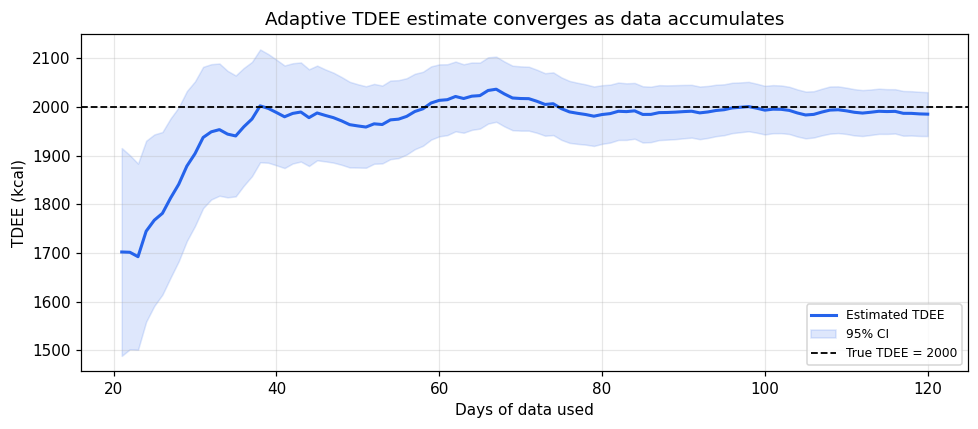

In [4]:
est = estimate_tdee(df)
print('Estimated TDEE :', est['tdee'], 'kcal   95% CI', (est['ci_low'], est['ci_high']))
print('True TDEE      :', gt.true_tdee, 'kcal')
print('Error          : %+.1f kcal' % (est['tdee'] - gt.true_tdee))
print('Truth in CI?   :', est['ci_low'] <= gt.true_tdee <= est['ci_high'])

exp = expanding_tdee(df)
fig, ax = plt.subplots()
ax.plot(exp.through_day, exp.tdee, color='#2563eb', lw=2, label='Estimated TDEE')
ax.fill_between(exp.through_day, exp.ci_low, exp.ci_high, color='#2563eb', alpha=0.15, label='95% CI')
ax.axhline(gt.true_tdee, color='black', ls='--', lw=1.2, label=f'True TDEE = {gt.true_tdee:.0f}')
ax.set_xlabel('Days of data used'); ax.set_ylabel('TDEE (kcal)')
ax.set_title('Adaptive TDEE estimate converges as data accumulates')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 4. Does cycle phase move scale weight? (hypothesis test)

We detrend weight (remove the fat-loss slope) to isolate short-term variation, then compare residuals across phases with one-way ANOVA and a targeted luteal-vs-follicular *t*-test with Cohen's *d*. The method should recover the luteal elevation we injected.

             mean    std  count
phase                          
menstrual   0.056  0.308     20
follicular -0.239  0.278     38
ovulation  -0.072  0.344     14
luteal      0.187  0.364     48

ANOVA across phases : F=12.36, p=4.49e-07
Luteal - follicular : +0.425 kg (p=2.62e-08, Cohen d=1.29)


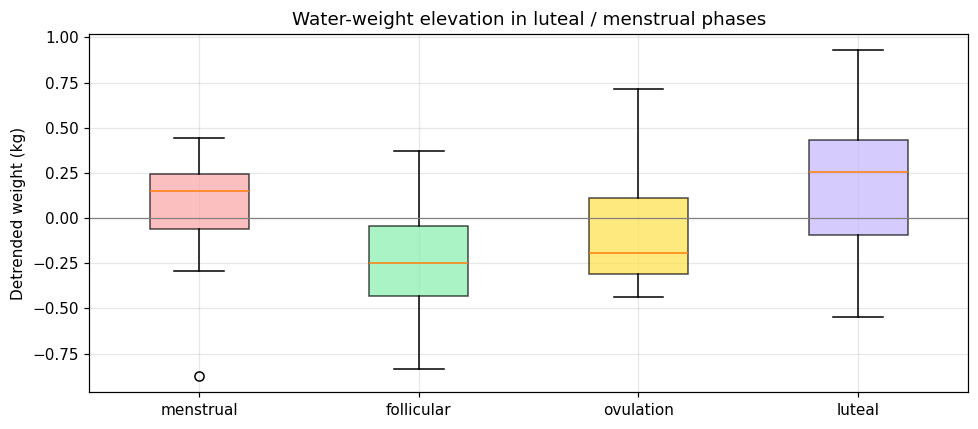

In [5]:
res = analyze(df)
print(res['by_phase'].to_string())
print()
print('ANOVA across phases : F=%.2f, p=%.2e' % (res['anova_F'], res['anova_p']))
print('Luteal - follicular : %+.3f kg (p=%.2e, Cohen d=%.2f)'
      % (res['luteal_vs_follicular_kg'], res['luteal_vs_follicular_p'], res['cohens_d']))

d2 = df.copy(); d2['resid'] = detrend_weight(d2)
groups = [d2.loc[d2.phase == p, 'resid'].values for p in PHASE_ORDER]
fig, ax = plt.subplots()
bp = ax.boxplot(groups, tick_labels=PHASE_ORDER, patch_artist=True)
for patch, p in zip(bp['boxes'], PHASE_ORDER):
    patch.set_facecolor(PHASE_COLORS[p]); patch.set_alpha(0.7)
ax.axhline(0, color='gray', lw=0.8)
ax.set_ylabel('Detrended weight (kg)')
ax.set_title('Water-weight elevation in luteal / menstrual phases')
plt.tight_layout(); plt.show()

## 5. Same code, real data

Nothing above is tied to synthetic data. Export your own history from the FemFit app (**Profile → Download my data**) and point the loader at the CSV:

```python
df, gt = load_data('my_femfit_export.csv')   # gt is None for real data
estimate_tdee(df)                            # same estimator
analyze(df)                                  # same test
```

With real data there is no ground-truth line to compare against — instead you compare the learned TDEE to the textbook estimate and watch it personalize over time. That learned value is fed back into the app's calorie engine.

## Takeaways

- **Adaptive TDEE** recovers the true maintenance level to within tens of kcal, with a calibrated CI — a data-driven replacement for a population formula.
- **Cycle-weight test** detects the injected luteal water effect at large effect size, validating FemFit's core message that pre-menstrual 'gain' is water, not fat.
- The pipeline is **source-agnostic** (synthetic ↔ real ↔ public) and wired back into the product, not a standalone notebook.